# Addiction & Health Issues Prediction

## 1. Introduction

The focus of this project is to build a predictive model to estimate the likelihood of an individual having health issues, based on addiction behaviours and other demographic data. It is important to note that the dataset used in this project is synthetic, meaning it was artificially generated and may not accurately reflect real-world distributions or patterns.



---

## 2. Dataset Summary and Cleaning

The Dataset Summary and Cleaning step involves reviewing the structure of the data, removing non-informative columns (such as id, name, and city), checking for and handling missing values, and ensuring that each variable is correctly formatted (e.g., numerical or categorical).

remove - This phase also includes validating the target variable (has_health_issues) and inspecting the distributions of features to identify any potential outliers or inconsistencies. These preparations are essential to ensure the dataset is clean, reliable, and ready for meaningful analysis and modeling.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("/content/drive/MyDrive/Python/addiction_population_data.csv")

# Drop irrelevant columns
df.drop(columns=["id", "name", "city"], inplace=True)

# Check for missing values
print(df.isnull().sum())

# Display data types
print(df.dtypes)

age                             0
gender                          0
country                         0
education_level               420
employment_status               0
annual_income_usd               0
marital_status                  0
children_count                  0
smokes_per_day                  0
drinks_per_week                 0
age_started_smoking             0
age_started_drinking            0
attempts_to_quit_smoking        0
attempts_to_quit_drinking       0
has_health_issues               0
mental_health_status            0
exercise_frequency              0
diet_quality                    0
sleep_hours                     0
bmi                             0
social_support                753
therapy_history              1014
dtype: int64
age                            int64
gender                        object
country                       object
education_level               object
employment_status             object
annual_income_usd              int64
marital_status   

## 3. Exploratory Data Analysis (EDA)

The Exploratory Data Analysis (EDA) phase focuses on understanding the main patterns and relationships within the data through visual and statistical techniques. It includes analyzing the distribution of the target variable (has_health_issues), exploring how numerical and categorical features vary across target classes, and identifying potential correlations between variables. By using plots such as histograms, count plots, and heatmaps, EDA helps reveal trends, outliers, or imbalances that could influence the modeling process, guiding both feature selection and model design.

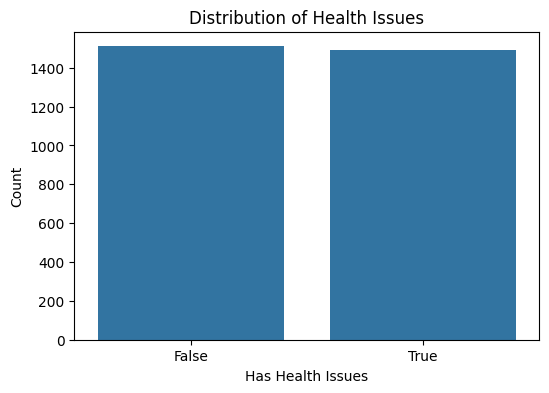

In [3]:
# -------------------------
# 1. Target Distribution
# -------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x="has_health_issues", data=df)
plt.title("Distribution of Health Issues")
plt.xlabel("Has Health Issues")
plt.ylabel("Count")
plt.show()

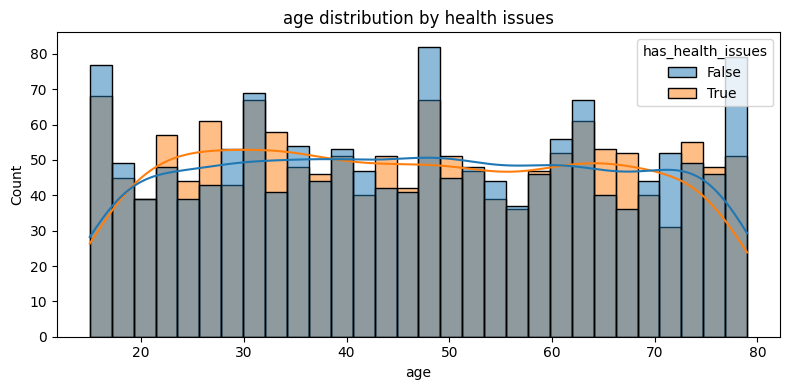

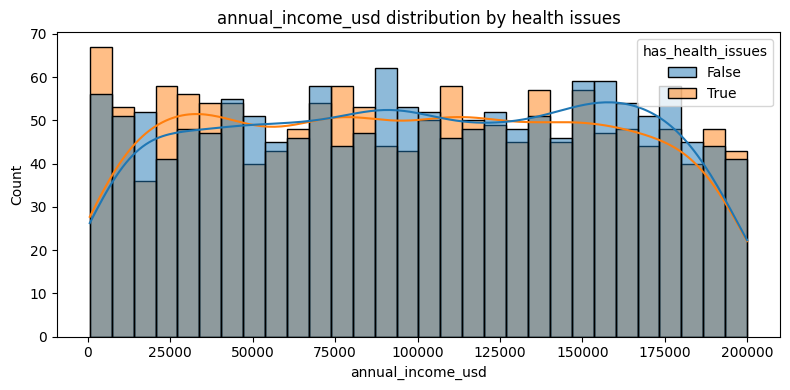

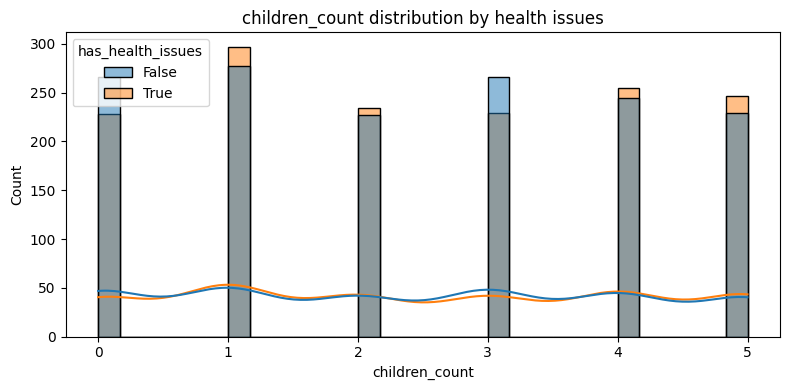

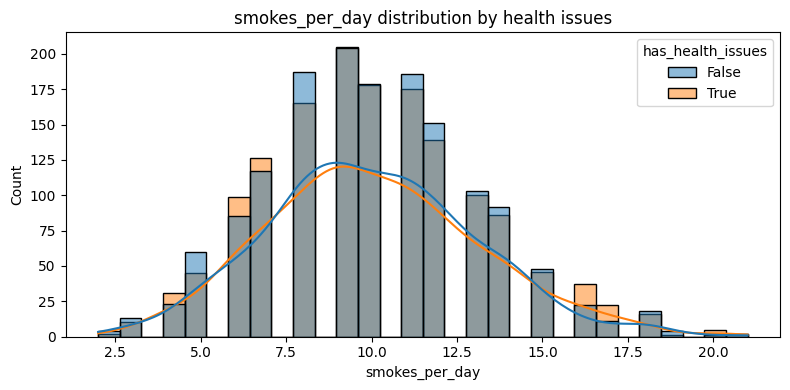

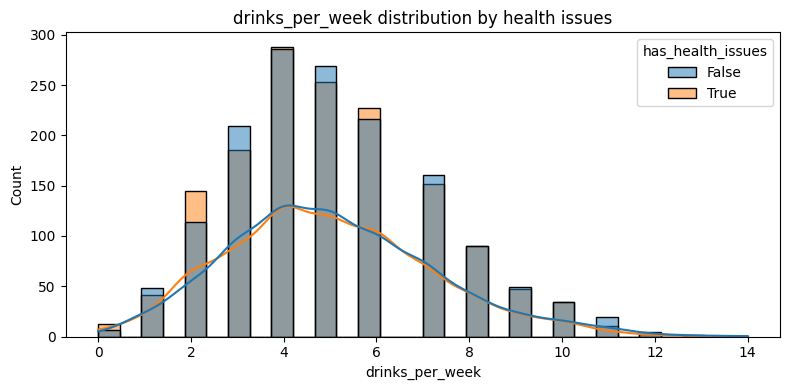

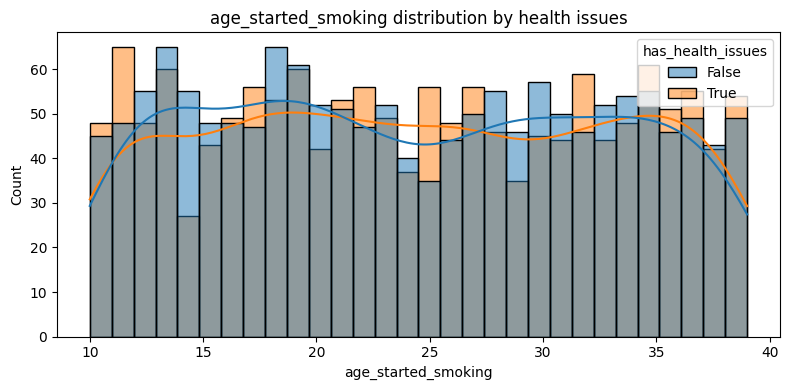

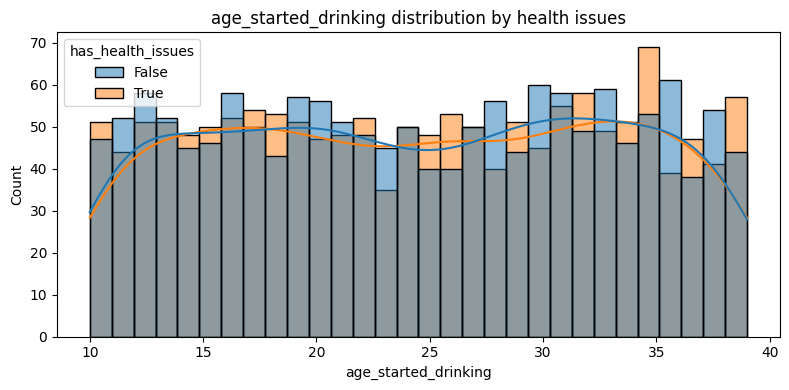

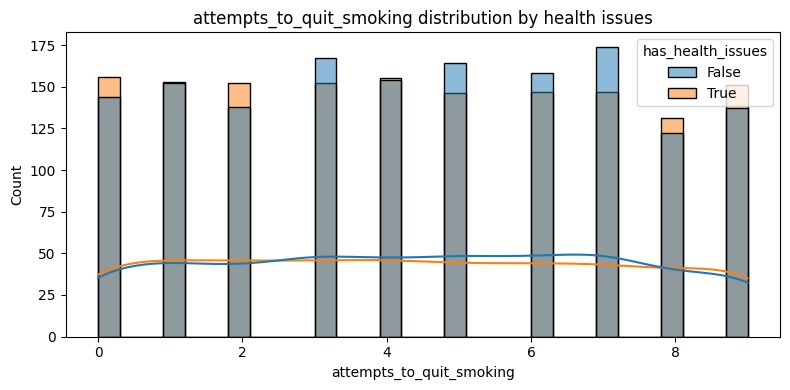

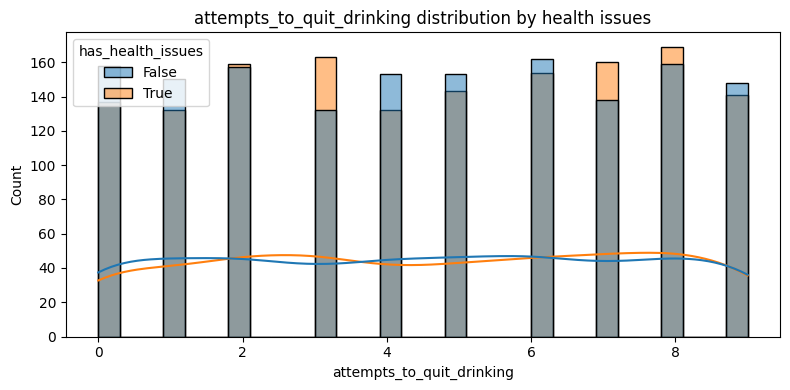

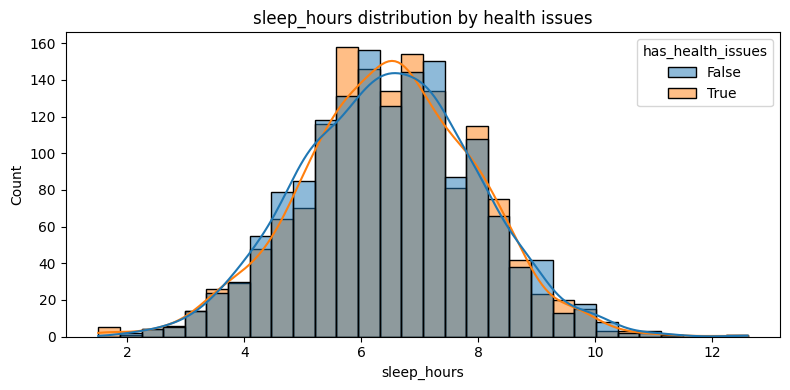

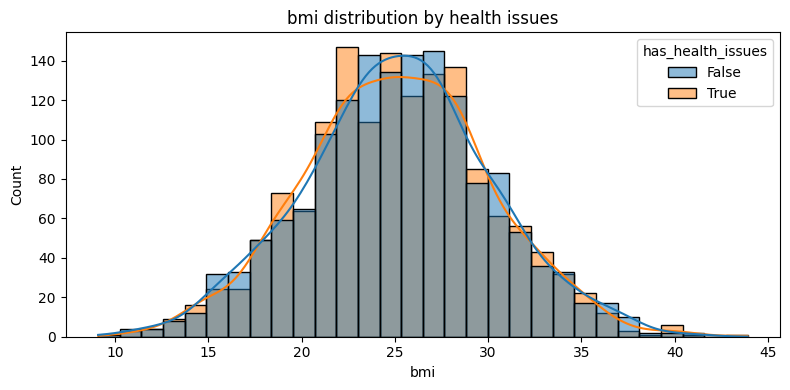

In [4]:
# -------------------------
# 2. Numeric Features
# -------------------------
numeric_features = [
    "age", "annual_income_usd", "children_count", "smokes_per_day",
    "drinks_per_week", "age_started_smoking", "age_started_drinking",
    "attempts_to_quit_smoking", "attempts_to_quit_drinking",
    "sleep_hours", "bmi"
]

for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue="has_health_issues", kde=True, bins=30)
    plt.title(f"{col} distribution by health issues")
    plt.tight_layout()
    plt.show()


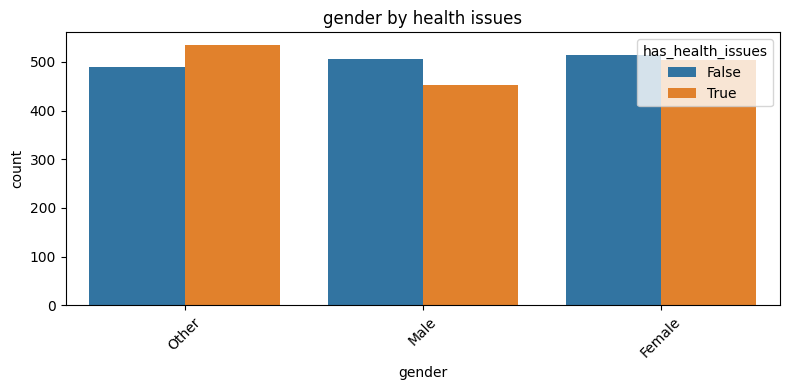

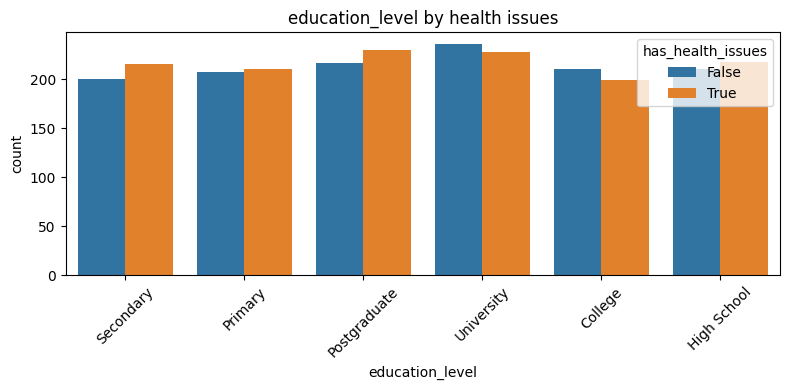

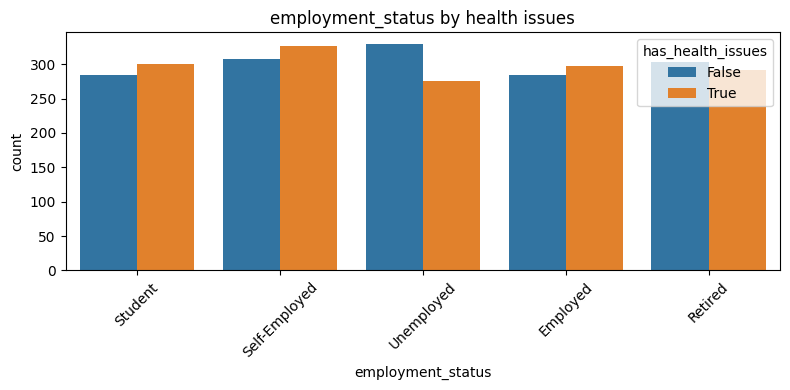

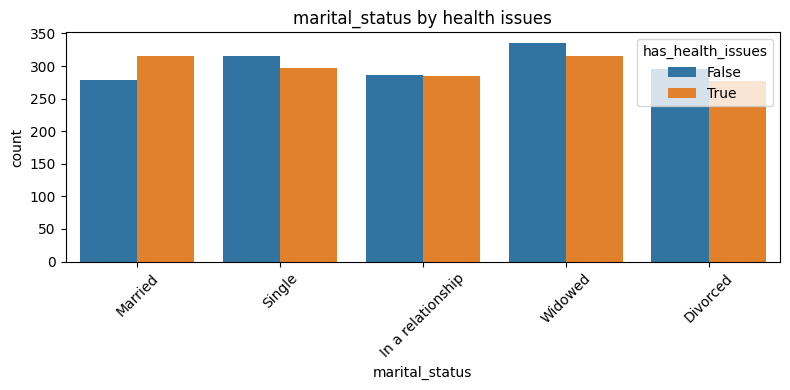

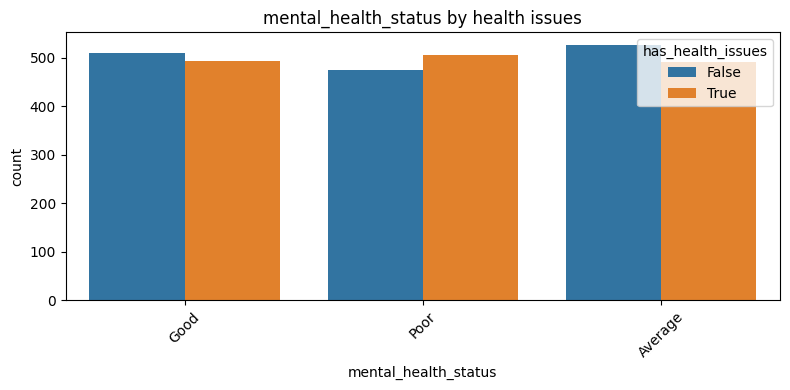

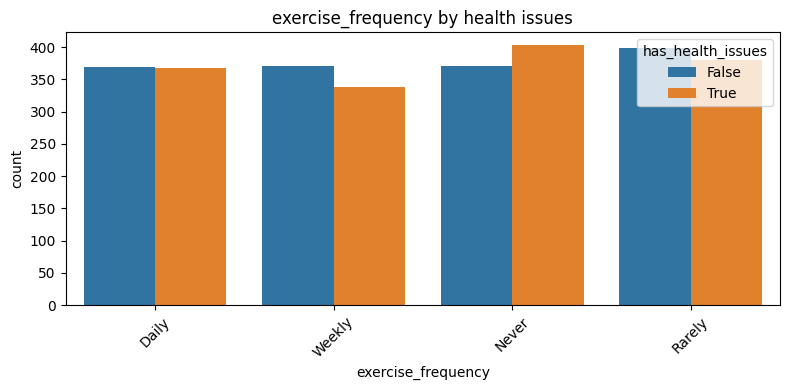

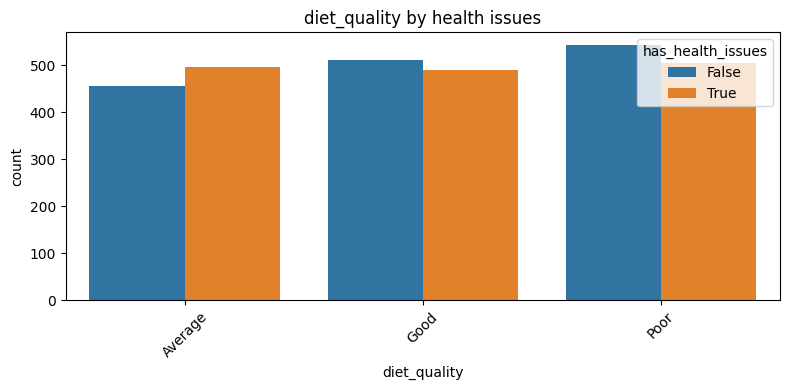

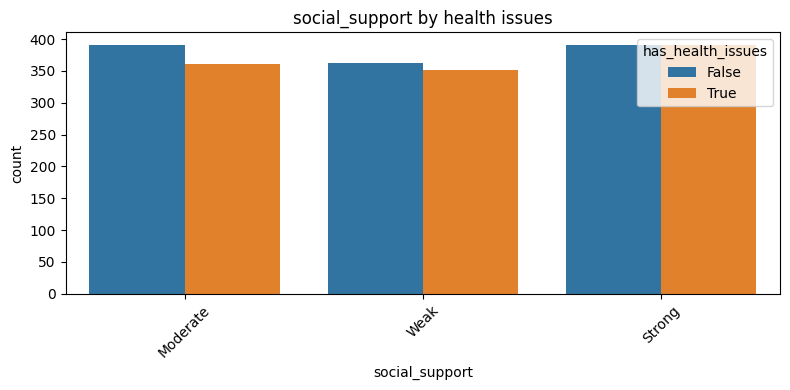

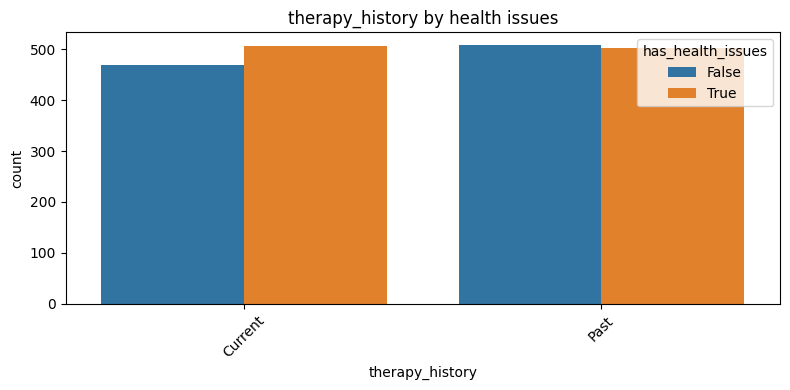

In [5]:
# -------------------------
# 3. Categorical Features
# -------------------------
categorical_features = [
    "gender", "education_level", "employment_status", "marital_status",
    "mental_health_status", "exercise_frequency", "diet_quality",
    "social_support", "therapy_history"
]

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="has_health_issues")
    plt.title(f"{col} by health issues")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


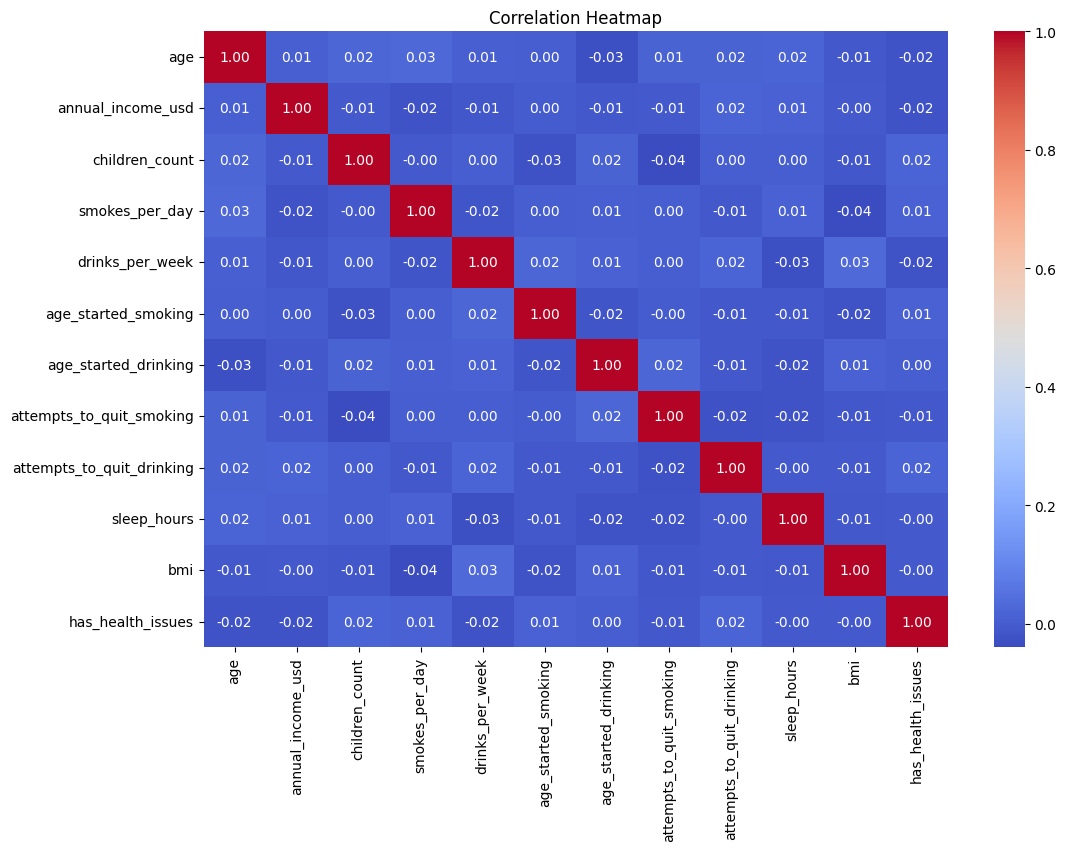

In [6]:
# -------------------------
# 4. Correlation Heatmap
# -------------------------
plt.figure(figsize=(12, 8))
corr = df[numeric_features + ["has_health_issues"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 4. Feature Engineering

The Feature Engineering step involves transforming and creating variables to enhance the dataset’s predictive power. This includes encoding categorical variables, scaling or normalizing numerical (not necessary in our case due to non-skewed values), and potentially combining or modifying existing features to capture more meaningful relationships (such as calculating ratios or interaction terms). The goal is to prepare a feature set that is both informative and suitable for the algorithms used in the modeling phase, improving the model's ability to learn relevant patterns in the data.

### "None" values are interpreted as Null, we will correct this





In [7]:
df.isnull().sum()

,0
age,0
gender,0
country,0
education_level,420
employment_status,0
annual_income_usd,0
marital_status,0
children_count,0
smokes_per_day,0
drinks_per_week,0


"None" values replaced by "Never":

In [8]:
df.fillna(value = "Never" , inplace = True)

In [9]:
df.isnull().sum()

,0
age,0
gender,0
country,0
education_level,0
employment_status,0
annual_income_usd,0
marital_status,0
children_count,0
smokes_per_day,0
drinks_per_week,0


In [10]:
# Convert categorical variables into dummies
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop("has_health_issues", axis=1)
y = df_encoded["has_health_issues"]

## 5. Modeling

The Modeling phase involves training and evaluating different machine learning algorithms to predict the likelihood of an individual having health issues based on the prepared features. In this project, we apply logistic regression  and random forests to compare their performance. The data is typically split into training and testing sets to assess how well each model generalizes to unseen data. Model performance is evaluated using appropriate classification metrics—such as accuracy, precision, recall, and the F1-score—which guide the selection of the most effective approach for the problem.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
              precision    recall  f1-score   support

       False       0.50      0.51      0.50       300
        True       0.49      0.48      0.49       300

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.49      0.49      0.49       600

AUC: 0.5133555555555556
Random Forest:
              precision    recall  f1-score   support

       False       0.51      0.56      0.53       300
        True       0.51      0.46      0.48       300

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600

AUC: 0.5067055555555555


### Results

The results from both the Logistic Regression and Random Forest models indicate weak predictive performance. The Logistic Regression model achieved an accuracy of 49% and an AUC of approximately 0.51, while the Random Forest model reached 51% accuracy with an AUC of 0.50. These values are close to what would be expected from random guessing, and the precision, recall, and F1-scores for both classes remain around 0.5 in both models, confirming a lack of meaningful classification.

This poor performance is mainly attributed to the use of a synthetic dataset, which may not capture the complexity, variability, and underlying patterns typically found in real-world data. Because of this, the models struggle to learn useful relationships, limiting their ability to generalize or make reliable predictions.

---

## 6. Interpretation

The Interpretation phase focuses on understanding the model’s outputs and evaluating how well it distinguishes between individuals with and without health issues. We use tools like the confusion matrix to assess the types of prediction errors made—such as false positives and false negatives—and to better understand model behavior beyond overall accuracy. Additionally, we examine feature importance scores to identify which variables most influence predictions. However, the quality of our results is limited by the nature of the dataset, which is synthetic and may not fully reflect real-world distributions or complexities. As a result, the models show limited predictive performance, highlighting the need for caution when interpreting outcomes based on artificial data.

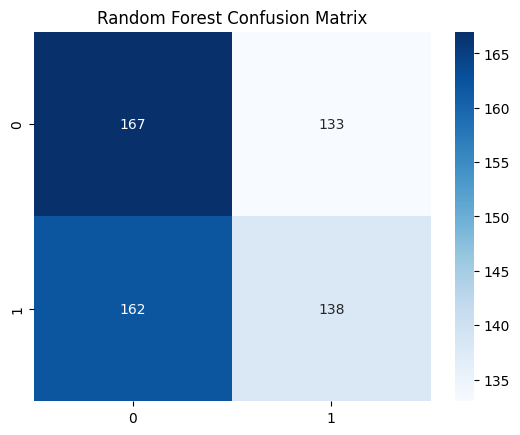

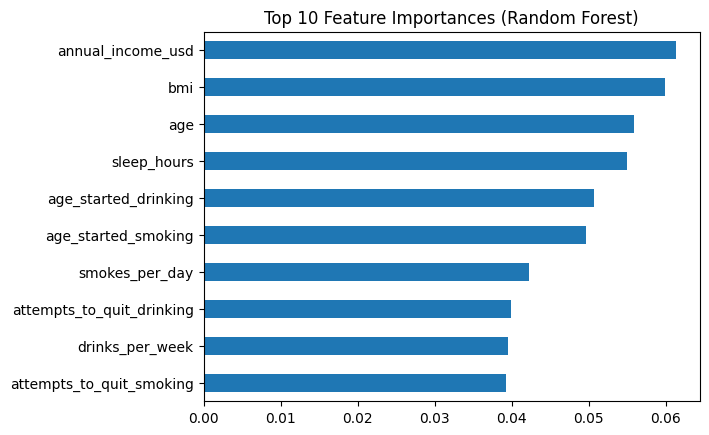

In [12]:
# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances[:10].plot(kind='barh')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## Plotting ROC Curve

The ROC curve illustrates how well the model separates the two classes by plotting the true positive rate against the false positive rate. The area under the curve (AUC) summarizes this performance, where 1.0 indicates perfect classification and 0.5 suggests no better than random guessing. In our case, the AUC is 0.49, which indicates that the model is not effectively distinguishing between individuals with and without health issues.

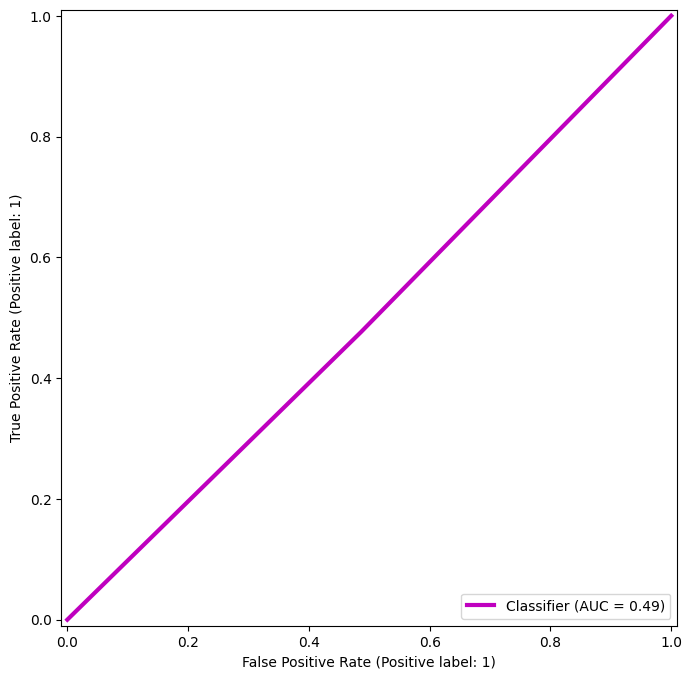

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(1,1,figsize=(12,8))
RocCurveDisplay.from_predictions(y_test, y_pred_lr, drop_intermediate = False, ax = ax, lw = 3, color ='m')
plt.show()